# Credit Risk EDA — Give Me Some Credit Dataset
**Author:** Anil Jhanwar | AI/ML Consultant

This notebook explores the dataset before model development.
Key questions we answer:
1. What is the overall default rate?
2. Which features have the most missing data?
3. How do features relate to default (univariate analysis)?
4. Are there extreme outliers that need capping?

In [1]:
from pathlib import Path
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

_ROOT = Path.cwd()
if _ROOT.name == "notebooks":
    _ROOT = _ROOT.parent
os.chdir(_ROOT)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

In [2]:
df = pd.read_csv("data/raw/cs-training.csv", index_col=0)
print(f"Dataset shape: {df.shape}")
print(f"\nFirst 5 rows:\n{df.head()}")

Dataset shape: (150000, 11)

First 5 rows:
   SeriousDlqin2yrs  RevolvingUtilizationOfUnsecuredLines  age  \
1                 1                              0.766127   45   
2                 0                              0.957151   40   
3                 0                              0.658180   38   
4                 0                              0.233810   30   
5                 0                              0.907239   49   

   NumberOfTime30-59DaysPastDueNotWorse  DebtRatio  MonthlyIncome  \
1                                     2   0.802982         9120.0   
2                                     0   0.121876         2600.0   
3                                     1   0.085113         3042.0   
4                                     0   0.036050         3300.0   
5                                     1   0.024926        63588.0   

   NumberOfOpenCreditLinesAndLoans  NumberOfTimes90DaysLate  \
1                               13                        0   
2                  


=== Target Variable ===
Non-default (0): 139,974 (93.3%)
Default    (1): 10,026 (6.7%)
Saved: outputs/eda_target_distribution.png


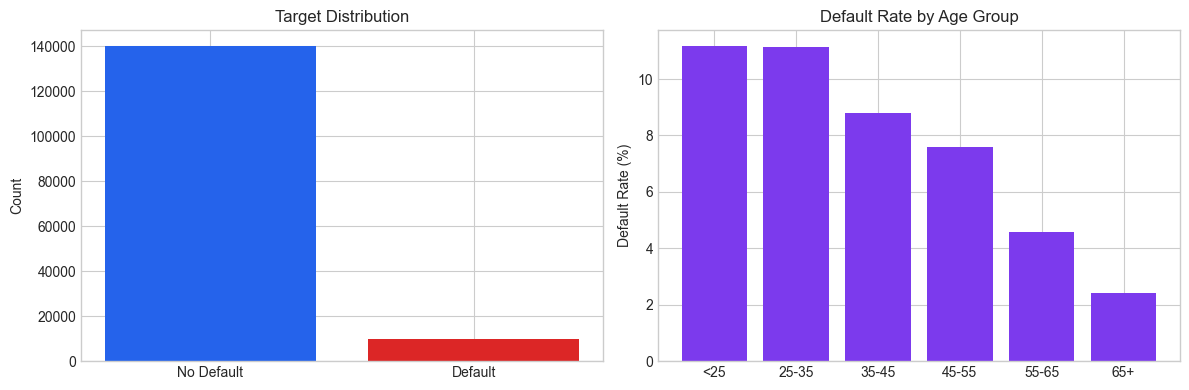

In [3]:
print("\n=== Target Variable ===")
target_counts = df["SeriousDlqin2yrs"].value_counts()
print(f"Non-default (0): {target_counts[0]:,} ({target_counts[0]/len(df):.1%})")
print(f"Default    (1): {target_counts[1]:,} ({target_counts[1]/len(df):.1%})")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].bar(["No Default", "Default"], target_counts.values, color=["#2563EB", "#DC2626"])
ax[0].set_title("Target Distribution")
ax[0].set_ylabel("Count")

# Default rate by age group
df["age_group"] = pd.cut(df["age"], bins=[0, 25, 35, 45, 55, 65, 100],
                          labels=["<25", "25-35", "35-45", "45-55", "55-65", "65+"])
default_by_age = df.groupby("age_group")["SeriousDlqin2yrs"].mean()
ax[1].bar(default_by_age.index, default_by_age.values * 100, color="#7C3AED")
ax[1].set_title("Default Rate by Age Group")
ax[1].set_ylabel("Default Rate (%)")
plt.tight_layout()
plt.savefig("outputs/eda_target_distribution.png", dpi=150)
print("Saved: outputs/eda_target_distribution.png")

In [4]:
print("\n=== Missing Values ===")
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (df.isnull().mean() * 100).sort_values(ascending=False)
missing_df = pd.DataFrame({"count": missing, "pct": missing_pct})
missing_df = missing_df[missing_df["count"] > 0]
print(missing_df)


=== Missing Values ===
                    count        pct
MonthlyIncome       29731  19.820667
NumberOfDependents   3924   2.616000
age_group              14   0.009333



=== Feature Analysis vs Default ===


Saved: outputs/eda_feature_distributions.png


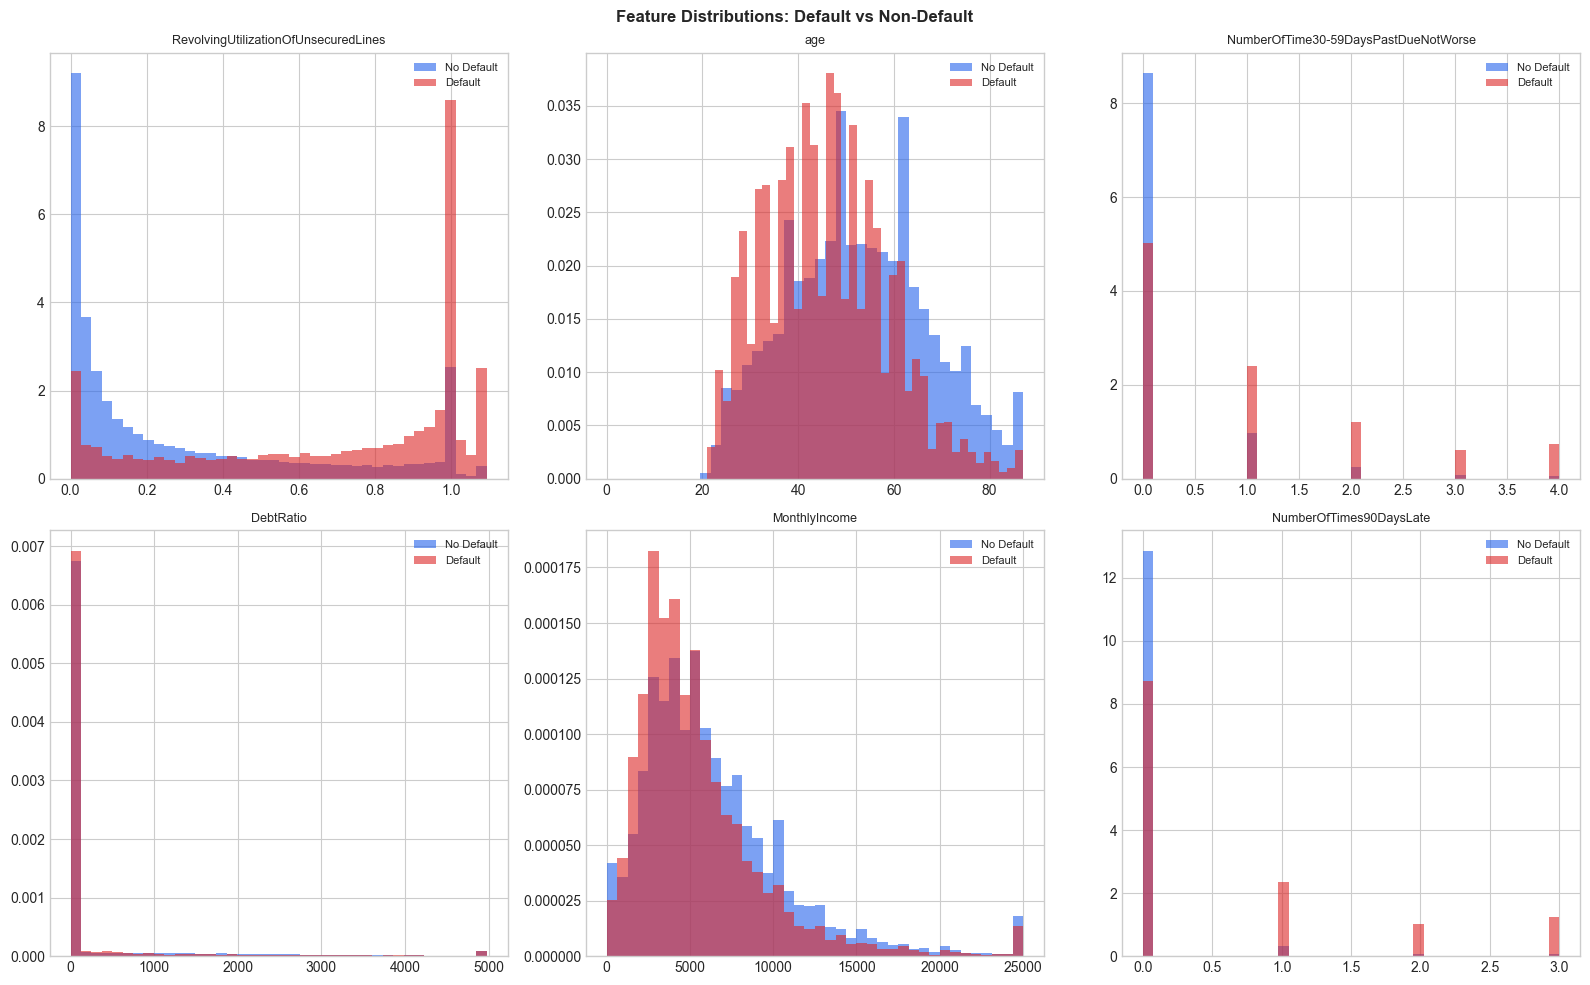

In [5]:
print("\n=== Feature Analysis vs Default ===")
feature_cols = [
    "RevolvingUtilizationOfUnsecuredLines",
    "age",
    "NumberOfTime30-59DaysPastDueNotWorse",
    "DebtRatio",
    "MonthlyIncome",
    "NumberOfTimes90DaysLate",
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    default_vals = df[df["SeriousDlqin2yrs"] == 1][col].dropna()
    nondefault_vals = df[df["SeriousDlqin2yrs"] == 0][col].dropna()

    # Clip for visualization
    p99 = df[col].quantile(0.99)
    default_vals = default_vals.clip(upper=p99)
    nondefault_vals = nondefault_vals.clip(upper=p99)

    axes[i].hist(nondefault_vals, bins=40, alpha=0.6, color="#2563EB",
                 label="No Default", density=True)
    axes[i].hist(default_vals, bins=40, alpha=0.6, color="#DC2626",
                 label="Default", density=True)
    axes[i].set_title(col, fontsize=9)
    axes[i].legend(fontsize=8)

plt.suptitle("Feature Distributions: Default vs Non-Default", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/eda_feature_distributions.png", dpi=150)
print("Saved: outputs/eda_feature_distributions.png")

In [6]:
print("\n=== Correlation with Default ===")
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_with_target = df[numeric_cols].corr()["SeriousDlqin2yrs"].sort_values(ascending=False)
print(corr_with_target)


=== Correlation with Default ===
SeriousDlqin2yrs                        1.000000
NumberOfTime30-59DaysPastDueNotWorse    0.125587
NumberOfTimes90DaysLate                 0.117175
NumberOfTime60-89DaysPastDueNotWorse    0.102261
NumberOfDependents                      0.046048
RevolvingUtilizationOfUnsecuredLines   -0.001802
NumberRealEstateLoansOrLines           -0.007038
DebtRatio                              -0.007602
MonthlyIncome                          -0.019746
NumberOfOpenCreditLinesAndLoans        -0.029669
age                                    -0.115386
Name: SeriousDlqin2yrs, dtype: float64


In [7]:
print("\n=== Outlier Analysis ===")
for col in feature_cols:
    p99 = df[col].quantile(0.99)
    p01 = df[col].quantile(0.01)
    n_outliers = ((df[col] > p99) | (df[col] < p01)).sum()
    print(f"  {col}: {n_outliers:,} outliers ({n_outliers/len(df):.1%}), "
          f"P1={p01:.2f}, P99={p99:.2f}")

print("\nEDA complete. Check outputs/ for charts.")


=== Outlier Analysis ===
  RevolvingUtilizationOfUnsecuredLines: 1,500 outliers (1.0%), P1=0.00, P99=1.09
  age: 2,535 outliers (1.7%), P1=24.00, P99=87.00
  NumberOfTime30-59DaysPastDueNotWorse: 850 outliers (0.6%), P1=0.00, P99=4.00
  DebtRatio: 1,500 outliers (1.0%), P1=0.00, P99=4979.04
  MonthlyIncome: 1,168 outliers (0.8%), P1=0.00, P99=25000.00
  NumberOfTimes90DaysLate: 873 outliers (0.6%), P1=0.00, P99=3.00

EDA complete. Check outputs/ for charts.
